# AS-AD Macroeconomic Model


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from as_ad_model import ASADModelClass

%load_ext autoreload
%autoreload 2


# 3. The AS-AD Model

We are using the file ASADModel.py which was imported in the top of the notebook

### Question 3.1

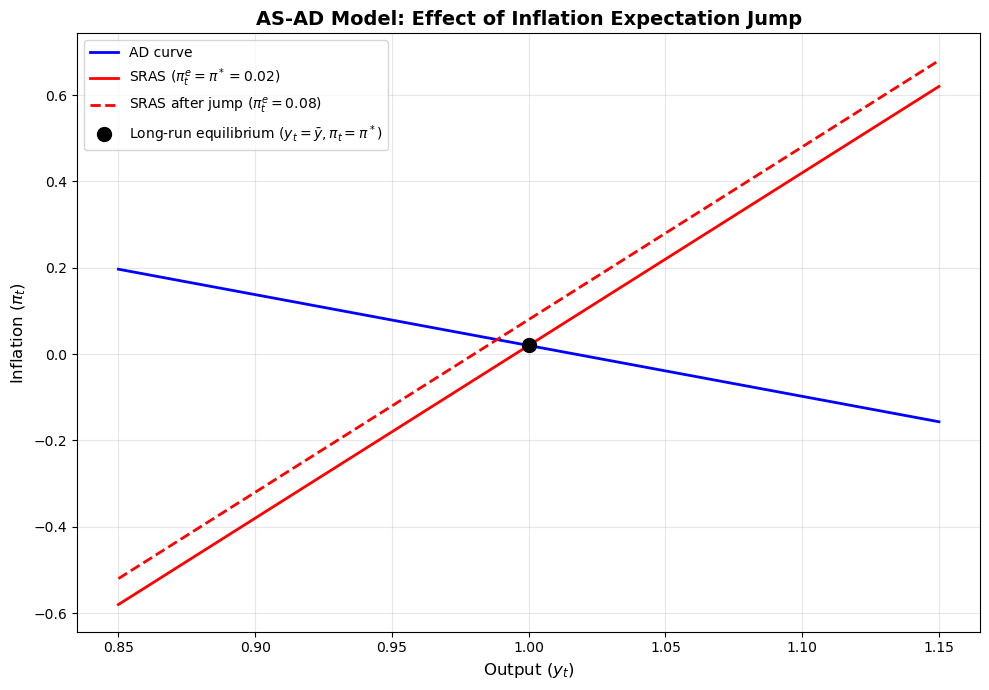

Long-run equilibrium: y = 1.0, π = 0.02
When π^e_t jumps from 0.02 to 0.08, the SRAS curve shifts upward by 0.06


In [31]:
model = ASADModelClass()

# Plot the effect of inflation expectation jump using method from py file
model.plot_expectation_jump(pi_e_initial=0.02, pi_e_jumped=0.08)


The SRAS curve is defined by equation (9), here we can se that higher expected inflation makes this move up. That happends because workers want a higher wage if they expect the prices to jump up, and the firms want higher prices immediately if the prices is expected to rise. However if this is only a temorary shock, the long run equilibrium is expected to stay put, and the SRAS curve will eventually get back to its original spot. Because expected inflation has an effect on actual inflation, it is important to try to keep the inflation expectations down, as this will effect actual inflation.

### Question 3.2

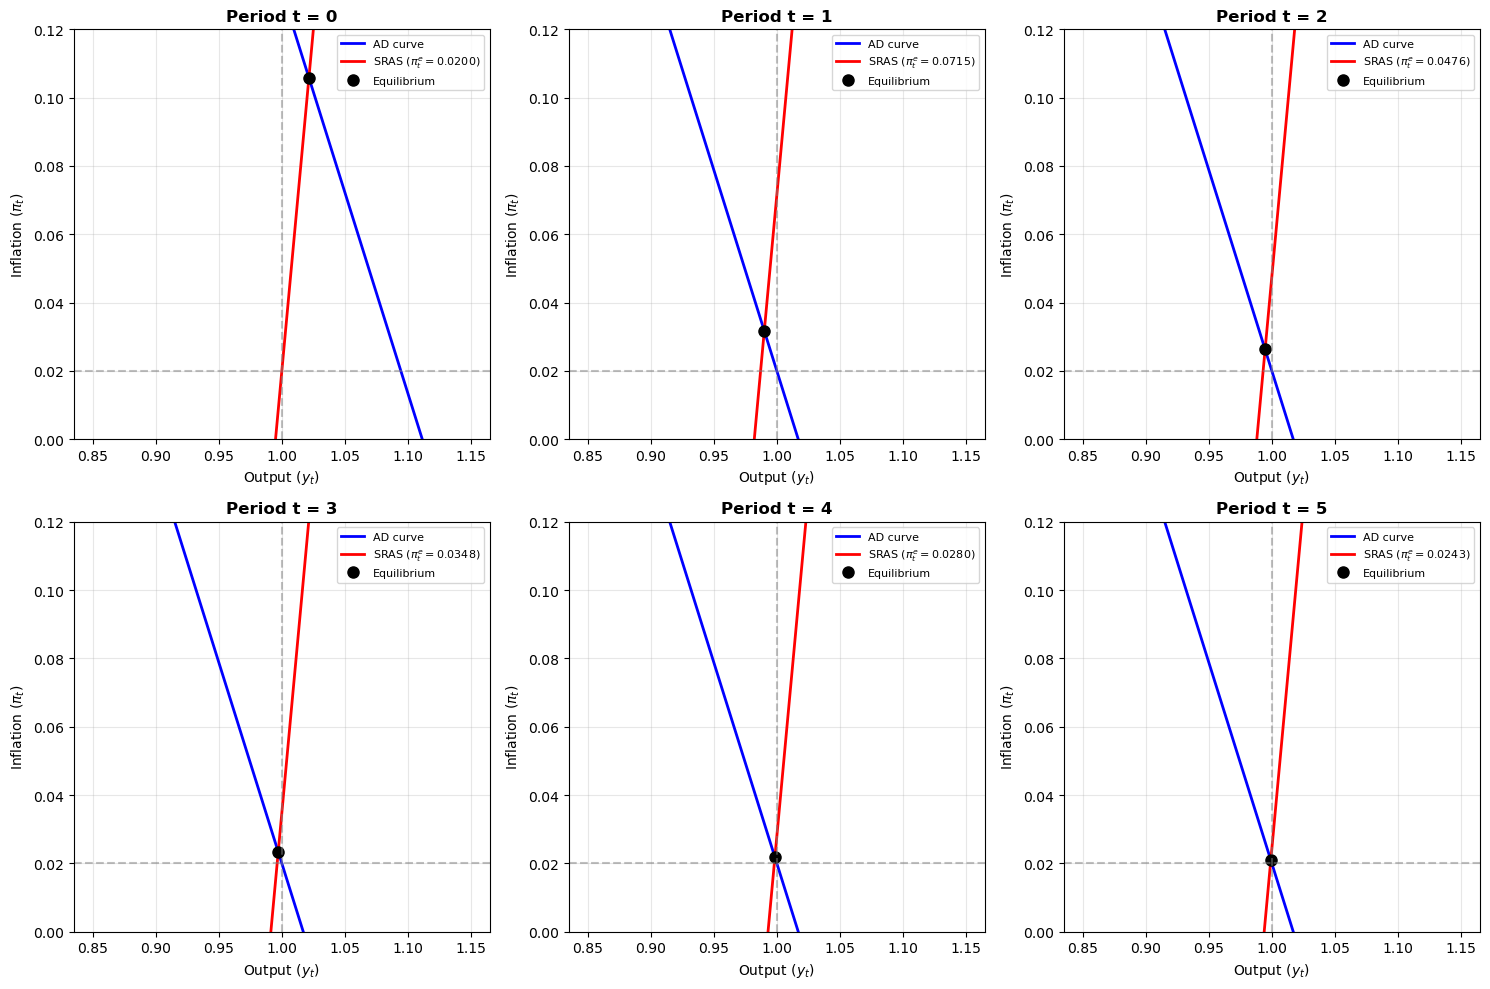

Simulation Results:
t    π^e_t       v_t       y*_t        π*_t        
0    0.0200      0.10      1.0215      0.1058      
1    0.0715      0.00      0.9901      0.0317      
2    0.0476      0.00      0.9947      0.0263      
3    0.0348      0.00      0.9971      0.0234      
4    0.0280      0.00      0.9985      0.0218      
5    0.0243      0.00      0.9992      0.0210      


In [32]:
# Get parameters from model
p = model.par

# Simulation parameters
T = 5  
phi = p['phi'] 

# Initialize arrays
pi_e = np.zeros(T + 1)
y_star = np.zeros(T + 1)
pi_star_sim = np.zeros(T + 1)

# Initial conditions
pi_e[0] = p['pi_star'] 
v = np.zeros(T + 1)
v[0] = 0.1  

# Simulate forward
for t in range(T + 1):
    y_star[t], pi_star_sim[t] = model.equilibrium(pi_e[t], v[t])
    
    if t < T:
        pi_e[t + 1] = phi * pi_star_sim[t] + (1 - phi) * pi_e[t]

# Plot period-by-period dynamics using py file
model.plot_period_dynamics(pi_e, v, y_star, pi_star_sim)

# Print results
print("Simulation Results:")
print(f"{'t':<5}{'π^e_t':<12}{'v_t':<10}{'y*_t':<12}{'π*_t':<12}")
for t in range(T + 1):
    print(f"{t:<5}{pi_e[t]:<12.4f}{v[t]:<10.2f}{y_star[t]:<12.4f}{pi_star_sim[t]:<12.4f}")

When t=0, we can see the expected inflation to be = 0,02, but since the shock hits, the actual inflation π* = 0,1058 due to the demand shock (v_t = 0,10). This also makes output go higher, as more goods are now wanted, and more good are therefore produced. The expected inflation for the next period is now higher as this shock still affects the expectations. This leads to a lower output leading to a lower actual inflation (expected inflation has a negative effect on output as given in equation 10). The effect from the shock is watered the more periods you go away from the shock, this i why the actual inflation is almost back at 2% as it was before the shock happend. If we had let the simulation go on for longer periods we would've seen the actual infaltion go back to 2% (as shown beneath)

In [33]:
# Extended simulation to show inflation will go back to 2%
T_extended = 10  
pi_e_ext = np.zeros(T_extended + 1)
y_star_ext = np.zeros(T_extended + 1)
pi_star_ext = np.zeros(T_extended + 1)
v_ext = np.zeros(T_extended + 1)

# Initial conditions
pi_e_ext[0] = p['pi_star'] 
v_ext[0] = 0.1  

# Simulate forward
for t in range(T_extended + 1):
    y_star_ext[t], pi_star_ext[t] = model.equilibrium(pi_e_ext[t], v_ext[t])
    
    if t < T_extended:
        pi_e_ext[t + 1] = phi * pi_star_ext[t] + (1 - phi) * pi_e_ext[t]

# Show only periods 6-10 to demonstrate convergence to 2%
print("\nExtended Simulation (t = 6 to 10):")
print(f"{'t':<5}{'π^e_t':<12}{'v_t':<10}{'y*_t':<12}{'π*_t':<12}")
for t in range(6, T_extended + 1):
    print(f"{t:<5}{pi_e_ext[t]:<12.4f}{v_ext[t]:<10.2f}{y_star_ext[t]:<12.4f}{pi_star_ext[t]:<12.4f}")


Extended Simulation (t = 6 to 10):
t    π^e_t       v_t       y*_t        π*_t        
6    0.0223      0.00      0.9996      0.0205      
7    0.0212      0.00      0.9998      0.0203      
8    0.0207      0.00      0.9999      0.0201      
9    0.0204      0.00      0.9999      0.0201      
10   0.0202      0.00      1.0000      0.0200      


### Question 3.3

In [34]:
# Setup simulation with parameters and seed  
T = 500
rho_values = [0.8, 0.5]
sigma_e = 0.01
np.random.seed(123)

# Generate random shocks
epsilon = np.random.normal(0, sigma_e, T)

# Run simulations for both rho values
results = {}

for rho in rho_values:
    results[rho] = model.simulate(rho, epsilon)


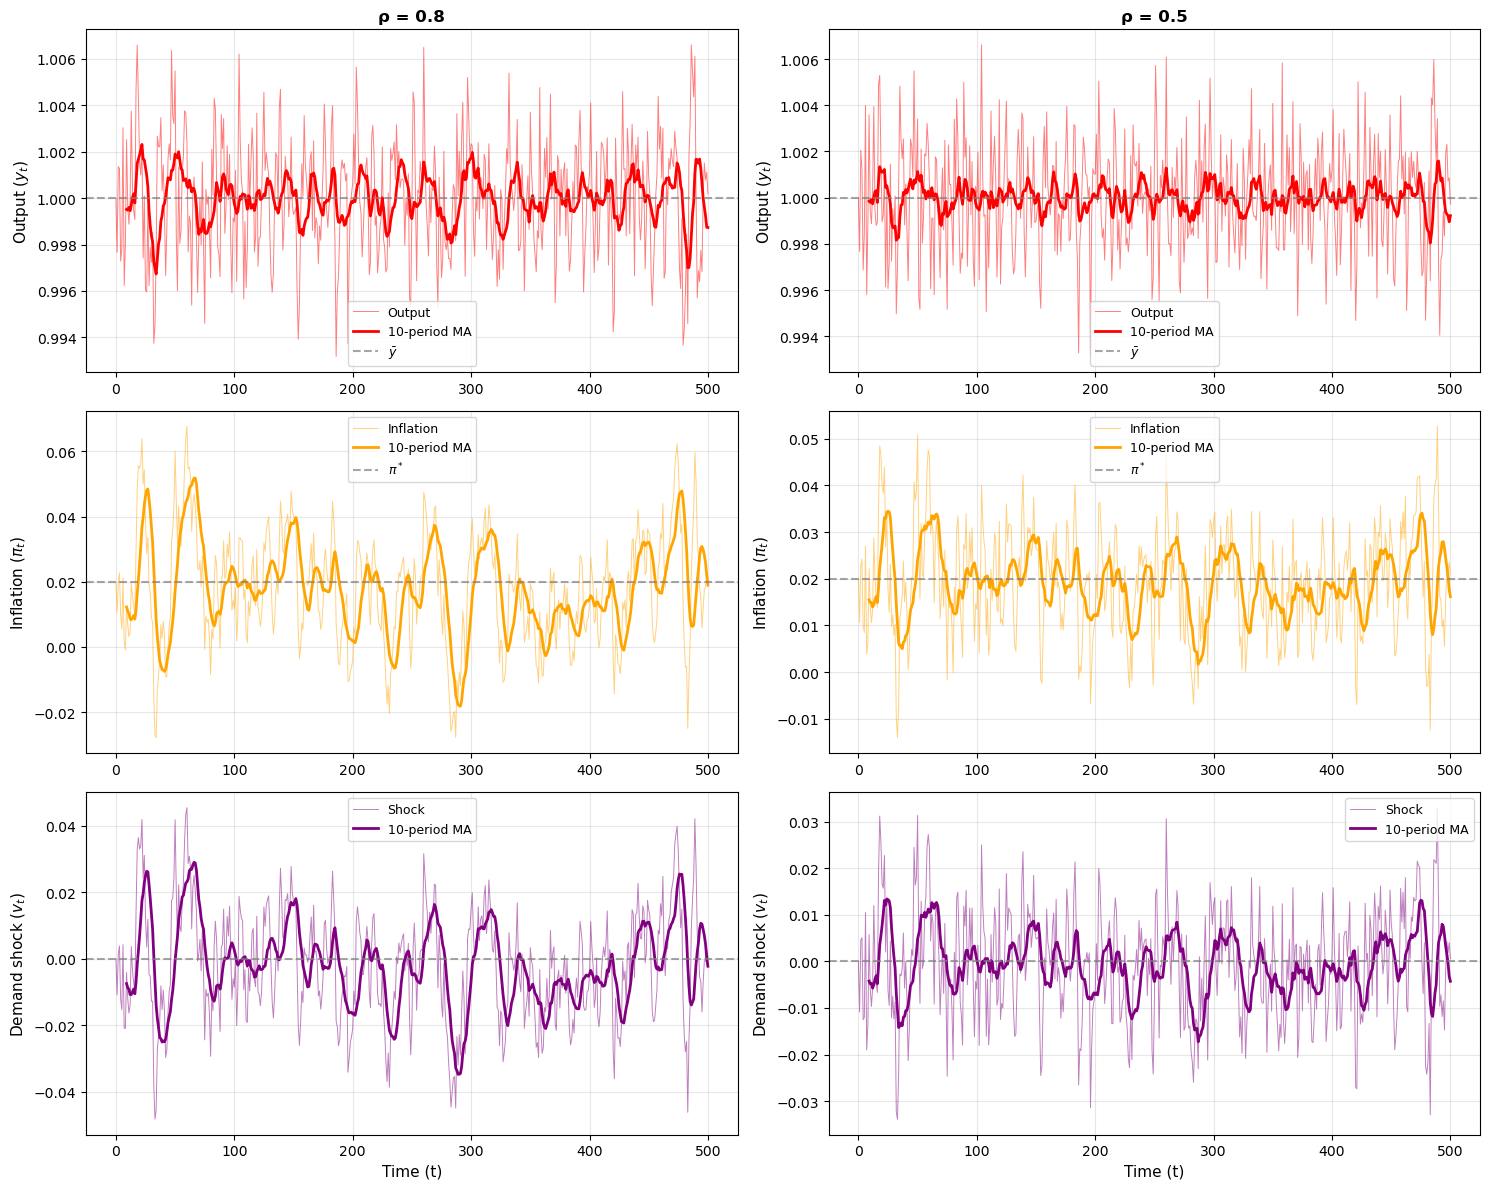

In [35]:
# Plot time series for both scenarios from py file
model.plot_simulation_results(results, rho_values, window=10)

Its clear to see that the shock is not nearly as big on average when ρ = 0,5. This makes sense as the ρ parameter decides how much of the shock is transfered to the next period. 

In [36]:
# Compute statistics using the models moments method
for rho in rho_values:
    y = results[rho]['y']
    pi = results[rho]['pi']
    
    # Use the moments method from pyfile
    stats = model.moments(y, pi)
    
    print(f"\nρ = {rho}:")
    print(f"Standard deviation of output gap: {stats['sd_y_gap']:.6f}")
    print(f"Standard deviation of inflation:  {stats['sd_pi']:.6f}")
    print(f"Correlation (y_gap, π):           {stats['corr']:.6f}")


ρ = 0.8:
Standard deviation of output gap: 0.002476
Standard deviation of inflation:  0.017263
Correlation (y_gap, π):           0.401556

ρ = 0.5:
Standard deviation of output gap: 0.002355
Standard deviation of inflation:  0.011224
Correlation (y_gap, π):           0.587516


Here we can also see that the ρ value plays a part, as the deviation is lower meaning the economy is more stable with a lover ρ value. This means the inflation and output gap, doesn't change as much when the ρ value is 0,5.